In [5]:
from __future__ import annotations

import os

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor

Matplotlib is building the font cache; this may take a moment.


In [6]:
# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    HERE = os.path.dirname(os.path.abspath(__file__))
except NameError:
    HERE = os.getcwd()
DATA_PATH = os.path.join(HERE, "Data", "BellhopData", "bellhop_monthly_original.csv")
MODEL_PATH = os.path.join(HERE, "Data", "BellhopData", "tl_residual_xgb_model.joblib")
IMPORTANCE_PATH = os.path.join(HERE, "Data", "BellhopData", "tl_residual_xgb_importance.csv")

# ── Features (XGBoost handles NaN natively; only `layer` needs encoding) ───────
NUMERIC = [
    "range_km", "log10_freq_hz",
    "src_seabed_depth_m", "rcv_seabed_depth_m",
    "path_min_depth_m", "path_mean_depth_m",
    "src_depth_m", "rcv_depth_m", "layer_mean_speed_ms",
]
BINARY = ["is_shadow", "month_sin", "month_cos"]
CATEGORICAL = ["layer"]
FEATURES = NUMERIC + BINARY + CATEGORICAL

XGB_PARAMS = dict(
    n_estimators=500, max_depth=3, learning_rate=0.05,
    subsample=0.7, colsample_bytree=0.7, min_child_weight=20,
    reg_lambda=5.0, reg_alpha=1.0, random_state=42, n_jobs=-1, verbosity=0,
)

In [7]:
RESULTS_DIR = os.path.join(HERE, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True )

In [ ]:
# Save results in unique directory
from coolname import generate_slug  # uv pip install coolname

def make_unique_dir():
    # generate_slug(2) = e.g. "happy-dog"
    unique_dir = os.path.join(RESULTS_DIR, generate_slug(2))
    if not os.path.exists(unique_dir):
        os.makedirs(unique_dir, exist_ok=True)
    return unique_dir


### The old code below for demonstration

# def make_unique_dir():
#     animal_list = ["dog", "cat", "mouse"]
#     adjective_list = ["happy", "sad", "hungry"]

#     animal = random.choice(animal_list)
#     adjective = random.choice(adjective_list)

#     unique_dir = os.path.join(RESULTS_DIR, f'{adjective}_{animal}')
    
#     if not os.path.exists(unique_dir):
#         os.makedirs(unique_dir)
#     return unique_dir

In [ ]:
def load_and_prepare() -> pd.DataFrame:
    """Load the dataset, drop Bellhop artifacts, add target + engineered features."""
    df = pd.read_csv(DATA_PATH)
    valid = (df["tl_bellhop_db"].notna() & np.isfinite(df["tl_bellhop_db"])
             & (df["tl_bellhop_db"] <= 160.0))
    print(f"Loaded {len(df)} rows; dropped {(~valid).sum()} invalid Bellhop values "
          f"-> {valid.sum()} remain")
    df = df[valid].copy()

    df["residual_db"] = df["tl_bellhop_db"] - df["tl_analytic_db"]
    df["log10_freq_hz"] = np.log10(df["freq_hz"])
    df["is_shadow"] = (df["shadow_penalty_db"] > 0).astype(float)
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    if "group_id" not in df.columns:
        # Legacy files (pre-`group_id`) tag geometry with `pair_i`, which repeats
        # across source_file — combine the two so pairs from different bands/months
        # aren't merged into one group.
        df["group_id"] = df["source_file"].astype(str) + "_" + df["pair_i"].astype(str)
    return df


def make_model() -> Pipeline:
    """XGBoost regressor with ordinal-encoded `layer`; other features passthrough."""
    pre = ColumnTransformer([
        ("num", "passthrough", NUMERIC),
        ("bin", "passthrough", BINARY),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1),
         CATEGORICAL),
    ], remainder="drop")
    return Pipeline([("prep", pre), ("xgb", XGBRegressor(**XGB_PARAMS))])


def _metrics(y_true: np.ndarray, y_pred: np.ndarray, label: str) -> None:
    print(f"  {label:6s} R2={r2_score(y_true, y_pred):.4f}  "
          f"RMSE={mean_squared_error(y_true, y_pred) ** 0.5:.3f} dB  "
          f"MAE={mean_absolute_error(y_true, y_pred):.3f} dB")


def _plot(df_test: pd.DataFrame, y_test: np.ndarray, y_pred: np.ndarray,
          imp: pd.DataFrame) -> None:
    colors = {"surface": "#2166ac", "mid": "#4dac26", "deep": "#d6604d"}
    df_test["_pred"] = y_pred

    fig, ax = plt.subplots(figsize=(6.5, 6.5))
    for layer, grp in df_test.groupby("layer"):
        ax.scatter(grp["residual_db"], grp["_pred"], s=10, alpha=0.5,
                   color=colors.get(layer, "gray"), label=layer)
    lims = [min(y_test.min(), y_pred.min()) - 2, max(y_test.max(), y_pred.max()) + 2]
    ax.plot(lims, lims, "k--", lw=0.8, label="1:1")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual residual (dB)"); ax.set_ylabel("Predicted residual (dB)")
    ax.set_title("XGBoost residual — test set"); ax.legend(markerscale=2)
    ax.grid(True, lw=0.3, alpha=0.4)
    fig.tight_layout()

    # Changed line here!!!!
    FIG_DIR = make_unique_dir()

    #everytime the code is ran i want to save a .txt file listing the hyperparameters saved in the same space as the graphs:
    with open(os.path.join(FIG_DIR, "paramaters.txt"), "w") as f:
        for key, value in XGB_PARAMS.items():
            print(f"{key} = {value}", file=f)

    

    

    fig.savefig(os.path.join(FIG_DIR, "xgb_actual_vs_predicted.png"), dpi=150)
    print(f"Saved {os.path.join(FIG_DIR, 'xgb_actual_vs_predicted.png')}")

    fig, ax = plt.subplots(figsize=(7, 5))
    y_pos = np.arange(len(imp))
    ax.barh(y_pos, imp["importance"], color="#377eb8", alpha=0.8)
    ax.set_yticks(y_pos); ax.set_yticklabels(imp["feature"], fontsize=9)
    ax.invert_yaxis(); ax.set_xlabel("Feature importance (gain)")
    ax.set_title("XGBoost feature importances")
    ax.grid(True, axis="x", lw=0.3, alpha=0.4)
    fig.tight_layout()
    fig.savefig(os.path.join(FIG_DIR, "xgb_feature_importance.png"), dpi=150)
    print(f"Saved {os.path.join(FIG_DIR, 'xgb_feature_importance.png')}")
    plt.close("all")

Loaded 23968 rows; dropped 864 invalid Bellhop values -> 23104 remain
Train: 18575 rows, 2473 pairs
Test:  4529 rows, 619 pairs

Fitting XGBoost...
Performance:
  train  R2=0.8056  RMSE=4.885 dB  MAE=3.154 dB
  test   R2=0.6761  RMSE=6.429 dB  MAE=3.839 dB

Feature importances:
            feature  importance
              layer    0.350078
          is_shadow    0.153942
        src_depth_m    0.138384
      log10_freq_hz    0.089743
           range_km    0.081976
          month_cos    0.043036
  path_mean_depth_m    0.040836
          month_sin    0.028272
 src_seabed_depth_m    0.019554
 rcv_seabed_depth_m    0.019240
layer_mean_speed_ms    0.018800
   path_min_depth_m    0.016139
        rcv_depth_m    0.000000
Saved /Users/jhughes/Desktop/transmission-loss/Data/BellhopData/tl_residual_xgb_importance.csv
Saved model -> /Users/jhughes/Desktop/transmission-loss/Data/BellhopData/tl_residual_xgb_model.joblib


AttributeError: 'function' object has no attribute 'items'

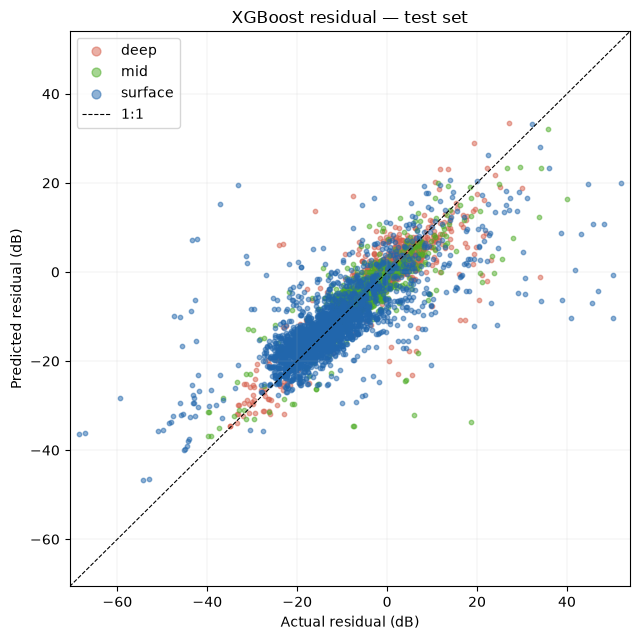

In [23]:
def run() -> None:
    df = load_and_prepare()
    X, y, groups = df[FEATURES], df["residual_db"].values, df["group_id"]

    gss = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    print(f"Train: {len(X_train)} rows, {groups.iloc[train_idx].nunique()} pairs")
    print(f"Test:  {len(X_test)} rows, {groups.iloc[test_idx].nunique()} pairs")

    print("\nFitting XGBoost...")
    model = make_model()
    model.fit(X_train, y_train)
    print("Performance:")
    _metrics(y_train, model.predict(X_train), "train")
    _metrics(y_test, model.predict(X_test), "test")

    # Feature importance
    imp = pd.DataFrame({
        "feature": FEATURES,
        "importance": model.named_steps["xgb"].feature_importances_,
    }).sort_values("importance", ascending=False)
    print("\nFeature importances:")
    print(imp.to_string(index=False))
    os.makedirs(os.path.dirname(IMPORTANCE_PATH), exist_ok=True)
    imp.to_csv(IMPORTANCE_PATH, index=False)
    print(f"Saved {IMPORTANCE_PATH}")

    

    # Refit on all rows and save (CV/test above is the honest estimate)
    final = make_model()
    final.fit(X, y)
    joblib.dump(final, MODEL_PATH)
    print(f"Saved model -> {MODEL_PATH}")

    _plot(df.iloc[test_idx].copy(), y_test, model.predict(X_test), imp)


run()